In [1]:
import os
os.listdir('/kaggle/input/datasets/adityajn105/flickr8k')

['captions.txt', 'Images']

In [2]:
with open('/kaggle/input/datasets/adityajn105/flickr8k/captions.txt','r')as f:
    for i in f:
        print(i.strip().split(","))
        break

['image', 'caption']


In [3]:
all_cap=dict()
with open('/kaggle/input/datasets/adityajn105/flickr8k/captions.txt','r')as f:
    for i in f:
        l=i.strip().split(",")
        if l[0] in all_cap:
            all_cap[l[0]].append(l[1])
        else:
            all_cap[l[0]]=[l[1]]

In [4]:
import re
for image,caption in all_cap.items():
    for i in range(len(caption)):
        caption[i] = caption[i].lower()
        caption[i] = re.sub(r"[^a-z\s]","",caption[i])
        caption[i] = "<start> " + caption[i] + " <end>"

In [5]:
all_cap["1000268201_693b08cb0e.jpg"]

['<start> a child in a pink dress is climbing up a set of stairs in an entry way  <end>',
 '<start> a girl going into a wooden building  <end>',
 '<start> a little girl climbing into a wooden playhouse  <end>',
 '<start> a little girl climbing the stairs to her playhouse  <end>',
 '<start> a little girl in a pink dress going into a wooden cabin  <end>']

In [6]:
del all_cap["image"]

In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer=Tokenizer(oov_token = "<unk>",filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')

In [8]:
captions=list()
for i,j in all_cap.items():
    captions.extend(j)

In [9]:
tokenizer.fit_on_texts(captions)

In [10]:
tokenizer.word_index["<start>"]

3

In [11]:
tokenizer.texts_to_sequences(['<start> a child in a pink dress is climbing up a set of stairs in an entry way  <end>'])

[[3, 2, 44, 5, 2, 89, 171, 8, 116, 53, 2, 392, 13, 384, 5, 29, 5063, 689, 4]]

In [12]:
tokenized_cap = {}

for i,j in all_cap.items():
    tokenized_cap[i] = tokenizer.texts_to_sequences(j)

In [13]:
tokenized_cap["1000268201_693b08cb0e.jpg"]

[[3, 2, 44, 5, 2, 89, 171, 8, 116, 53, 2, 392, 13, 384, 5, 29, 5063, 689, 4],
 [3, 2, 20, 311, 64, 2, 195, 120, 4],
 [3, 2, 38, 20, 116, 64, 2, 195, 2357, 4],
 [3, 2, 38, 20, 116, 6, 384, 21, 63, 2357, 4],
 [3, 2, 38, 20, 5, 2, 89, 171, 311, 64, 2, 195, 2892, 4]]

In [14]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import img_to_array, load_img

In [19]:
os.listdir('/kaggle/input/datasets/adityajn105/flickr8k/Images')[:5]

['3226254560_2f8ac147ea.jpg',
 '214543992_ce6c0d9f9b.jpg',
 '2366643786_9c9a830db8.jpg',
 '3368819708_0bfa0808f8.jpg',
 '2190227737_6e0bde2623.jpg']

In [27]:
image = load_img('/kaggle/input/datasets/adityajn105/flickr8k/Images/214543992_ce6c0d9f9b.jpg',target_size=(128,128))

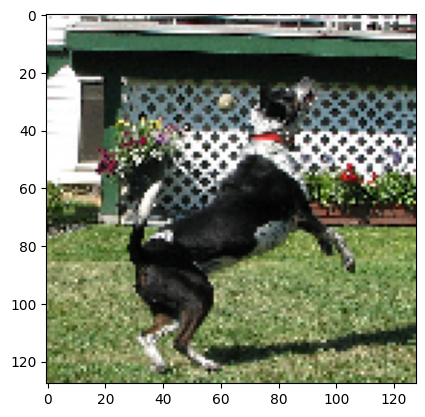

['<start> a black and white dog is playing with a ball on a lawn  <end>',
 '<start> a black and white dog jumps up as a ball is thrown over his head  <end>',
 '<start> dog jumping looking up and small white ball in air passed by <end>',
 '<start> the black and white dog is attempting to catch a ball in the garden  <end>',
 '<start> the dog jumps up waiting to catch something being thrown  <end>']

In [29]:
plt.imshow(image)
plt.show()
all_cap['214543992_ce6c0d9f9b.jpg']

In [30]:
arr_img = img_to_array(image)

In [31]:
arr_img.shape

(128, 128, 3)

In [35]:
arr_img/arr_img.max()

array([[[0.9882353 , 0.9882353 , 0.98039216],
        [0.9882353 , 0.9882353 , 0.9882353 ],
        [0.9843137 , 0.9843137 , 0.9843137 ],
        ...,
        [1.        , 1.        , 1.        ],
        [0.39215687, 0.2627451 , 0.3372549 ],
        [0.24705882, 0.2627451 , 0.25882354]],

       [[0.99607843, 1.        , 1.        ],
        [0.7490196 , 0.7490196 , 0.7490196 ],
        [0.99607843, 0.99607843, 0.99607843],
        ...,
        [1.        , 0.9882353 , 0.99215686],
        [0.41568628, 0.28235295, 0.34901962],
        [0.29803923, 0.29803923, 0.2901961 ]],

       [[0.99607843, 0.99607843, 0.99607843],
        [0.99607843, 0.99607843, 0.99607843],
        [1.        , 1.        , 1.        ],
        ...,
        [0.9647059 , 0.9882353 , 0.9882353 ],
        [0.6156863 , 0.4       , 0.49019608],
        [0.6901961 , 0.29803923, 0.44705883]],

       ...,

       [[0.41960785, 0.46666667, 0.20784314],
        [0.49803922, 0.53333336, 0.3254902 ],
        [0.35686275, 0

In [37]:
all_img = dict()
for i in all_cap.keys():
    path='/kaggle/input/datasets/adityajn105/flickr8k/Images/' +  i
    image = load_img(path,target_size=(128,128))
    arr_img = img_to_array(image)
    arr=arr_img/255
    all_img[i]= arr

In [40]:
all_img['214543992_ce6c0d9f9b.jpg'].shape

(128, 128, 3)